In [1]:
from importlib.metadata import version
print("torch version:", version("torch"))

torch version: 2.7.0+cu128


In [2]:
import torch
import math
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass

from ROPE import ROPE, apply_rotary_pos_emb

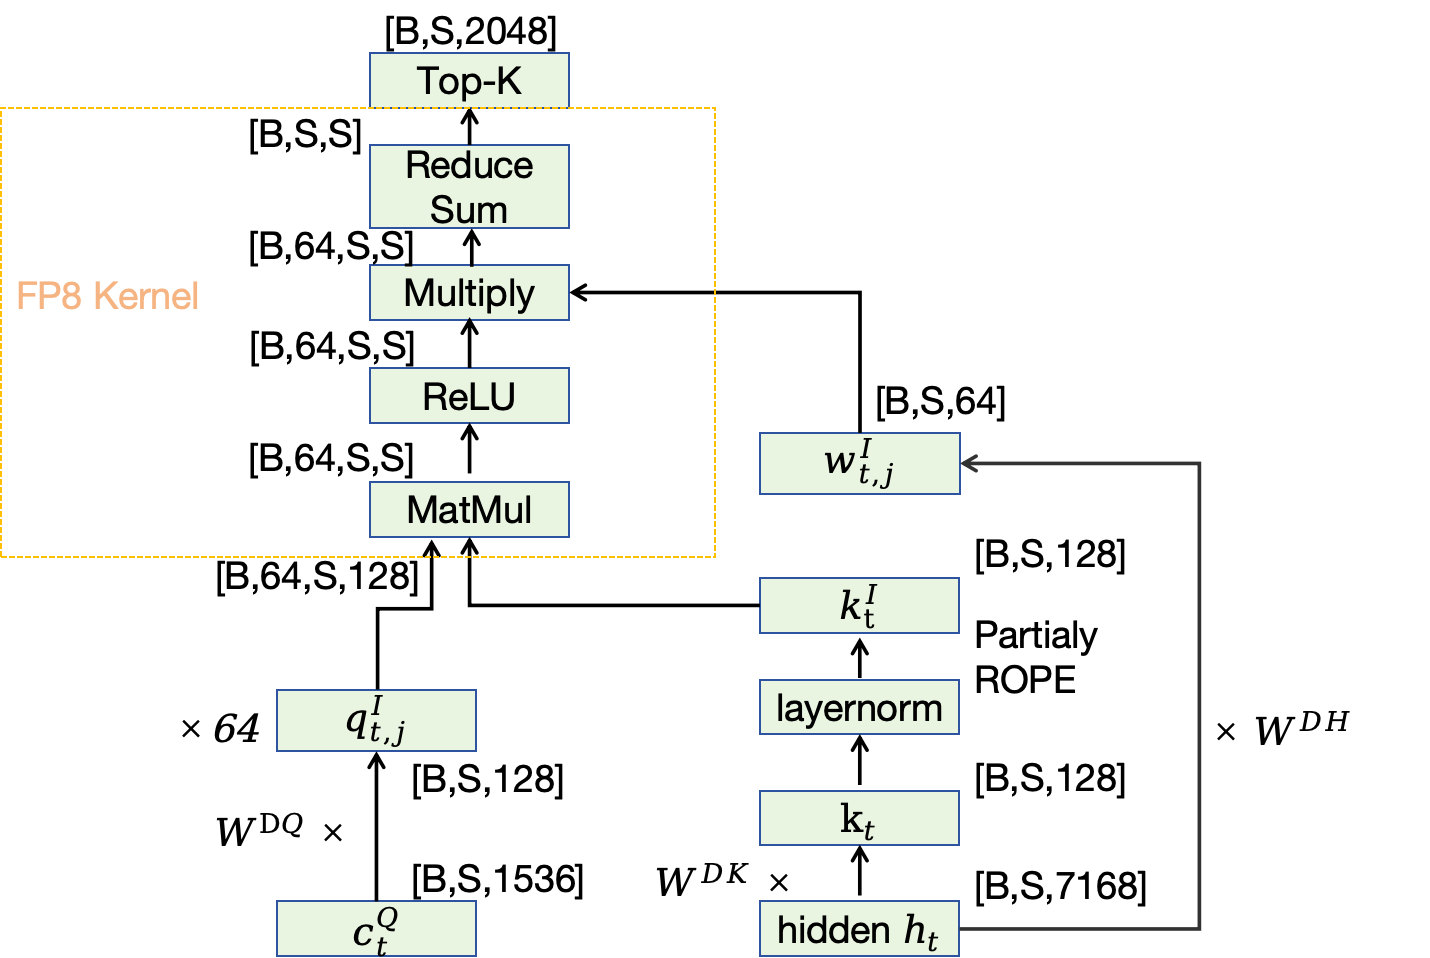

In [5]:
from IPython.display import Image, display

# 替换为你的桌面路径（关键！）
# Windows 示例: 'C:/Users/你的用户名/Desktop/MLA-Prefill.png'
# macOS/Linux 示例: '/Users/你的用户名/Desktop/MLA-Prefill.png'
image_path = r'C:/Users/1/Desktop/DSA.png'  # ← 修改这里！

display(Image(filename=image_path))

# 手写 DSA

In [5]:
@dataclass
class Config:
    hidden_size: int
    n_heads: int
    max_pos: int
    rope_theta: float
    rope_head_dim: int
    q_lora_rank: int
    kv_lora_rank: int
    head_dim: int
    dropout: float

    # 新增参数
    index_heads: int
    index_head_dim: int
    index_topk: int

In [37]:
class Indexer(nn.Module):
    """ DSA Indexer核心代码实现
    """
    def __init__(self, config):
        super().__init__()

        self.hidden_size = config.hidden_size
        self.index_heads = config.index_heads
        self.head_dim = config.index_head_dim
        self.rope_head_dim = config.rope_head_dim
        self.q_lora_rank = config.q_lora_rank
        self.index_topk = config.index_topk

        # 初始化 W_dq, W_dk, W_dh
        self.w_dq = nn.Linear(self.q_lora_rank, self.index_heads * self.head_dim, bias=False)
        self.w_dk = nn.Linear(self.hidden_size, self.head_dim, bias=False)
        self.w_dh = nn.Linear(self.hidden_size, self.index_heads, bias=False)

        # k的归一化层
        self.k_norm = nn.LayerNorm(self.head_dim)

        # 初始化 ROPE 的类
        self.rotary_emb = ROPE(
            self.rope_head_dim,
            config.max_pos,
            config.rope_theta
        )


    def forward(self, hidden_states, qr, position_ids, attention_mask=None):
        batch, seq_len, hidden_size = hidden_states.size()

        # 对c_tq 降维得到q_tj
        # [batch, seq_len, index_heads * head_dim]
        q = self.w_dq(qr)
        q = q.view(batch, seq_len, self.index_heads, self.head_dim).transpose(1, 2)
        
        # 切分 q_pe 和 q_nope
        q_pe, q_nope = torch.split(q, [self.rope_head_dim, self.head_dim - self.rope_head_dim], dim=-1)

        # apply ROPE
        # [batch, index_heads, seq_len, rope_head_dim]
        cos, sin = self.rotary_emb(q_pe)
        q_pe = apply_rotary_pos_emb(q_pe, cos, sin, position_ids)
        # [batch, index_heads, seq_len, head_dim]
        q = torch.cat([q_pe, q_nope], dim=-1)

        # 对 hidden states 降维，得到kt
        k = self.w_dk(hidden_states)
        # [batch, 1, seq_len, head_dim]
        k = self.k_norm(k).unsqueeze(1)
        # 切分 q_pe 和 q_nope
        k_pe, k_nope = torch.split(k, [self.rope_head_dim, self.head_dim - self.rope_head_dim], dim=-1)
        
        # apply ROPE
        # [batch, 1, seq_len, rope_head_dim]
        cos, sin = self.rotary_emb(k_pe)
        k_pe = apply_rotary_pos_emb(k_pe, cos, sin, position_ids)
        # [batch, 1, seq_len, head_dim]
        k = torch.cat([k_pe, k_nope], dim=-1)

        # 对 hidden states 映射得到 head的权重
        #  [batch, seq_len, index_heads]
        weights = self.w_dh(hidden_states)
        # [batch, index_heads, seq_len, 1]
        weights = weights.transpose(1, 2).unsqueeze(-1)

        # 对 k 复制 index_heads 份
        # [batch, index_heads, seq_len, head_dim]
        k = k.repeat_interleave(self.index_heads, dim=1)

        # 计算q,k内积得到 indexer 重要得分
        scale = self.head_dim ** (-0.5)
        # [batch, index_heads, seq_len, seq_len]
        # print(11, q.shape, k.shape)
        attn = torch.matmul(q, k.transpose(-1, -2)) * scale

        # 加一个 relu 激活
        attn = F.relu(attn)

        # 对每一个头的 attn 做重要性加权
        # 对 head 做 sum(w_tj .* relu(q_tj * k_t^T))
        # [batch, seq_len, seq_len]
        index_score = torch.sum(weights * attn, dim=1)

        # 加 casual mask
        if attention_mask is not None:
            index_score = torch.masked_fill(
                index_score,
                attention_mask,
                float('-inf')
            )

        # 选top_k
        topk_indices = index_score.topk(min(self.index_topk, seq_len), dim=-1)[1]

        return index_score, topk_indices

In [38]:
class DSA(nn.Module):
    """DSA Prefill阶段的核心实现"""

    def __init__(self, config):
        super().__init__()

        self.dropout = config.dropout
        self.hidden_size = config.hidden_size
        self.n_heads = config.n_heads
        self.max_pos = config.max_pos
        self.rope_theta = config.rope_theta

        # 对应于query压缩的向量，在deepseek v3中，hidden_size 7168
        # 压缩后的kv d_c=512, 压缩比例 1/14
        # q的压缩为1536，压缩比例为 1/4.7
        # rope的维度是 64

        # 对应 query 的压缩向量
        self.q_lora_rank = config.q_lora_rank

        # 对应query 和 key进行rope的维度
        self.rope_head_dim = config.rope_head_dim

        # 对应 key, value的压缩向量
        self.kv_lora_rank = config.kv_lora_rank

        # 对应每一个head的维度
        self.head_dim = config.head_dim

        # 对应Q， K做attention的维度，nope_dim + rope_dim
        self.q_head_dim = config.head_dim + config.rope_head_dim

        # Q的降维和升维
        self.q_down_proj = nn.Linear(
            self.hidden_size,
            self.q_lora_rank,
            bias=False
        )

        self.q_up_proj = nn.Linear(
            self.q_lora_rank,
            self.n_heads * self.q_head_dim,
            bias=False
        )

        # KV的降维和升维
        self.kv_down_proj = nn.Linear(
            self.hidden_size,
            self.kv_lora_rank + self.rope_head_dim,
            bias=False
        )

        self.kv_up_proj = nn.Linear(
            self.kv_lora_rank,
            self.n_heads * (self.head_dim + self.head_dim),
            # 最终还需要做切分，一部分是K的，一部分是V的
            bias=False
        )

        # 输出映射层 O
        self.o_proj = nn.Linear(
            self.n_heads * self.head_dim,
            self.hidden_size,
            bias=False
        )

        # 初始化 ROPE 的类
        self.rotary_emb = ROPE(
            self.rope_head_dim,
            self.max_pos,
            self.rope_theta
        )

        # 初始化 indexer
        self.indexer = Indexer(config)

    def forward(
        self,
        hidden_states,
        attention_mask = None,
        position_ids = None
    ):
        """
        MLA Prefill阶段的核心实现
        """
        bsz, q_len, _ = hidden_states.size()

        # 1. Q的降维升维映射，以及NOPE和ROPE切分
        qr = self.q_down_proj(hidden_states)
        q = self.q_up_proj(qr)
        q = q.view(bsz, q_len, self.n_heads, self.q_head_dim).transpose(1, 2)
        q_nope, q_pe = torch.split(q,
            [self.head_dim, self.rope_head_dim],
            dim=-1
        )

        # 2.KV的降维升维映射，以及NOPE和ROPE切分
        compressed_kv = self.kv_down_proj(hidden_states)
        compressed_kv, k_pe = torch.split(compressed_kv,
            [self.kv_lora_rank, self.rope_head_dim],
            dim=-1
        )
        k_pe = k_pe.view(bsz, q_len, 1, self.rope_head_dim).transpose(1, 2)
        kv = self.kv_up_proj(compressed_kv)
        kv = kv.view(bsz, q_len, self.n_heads, self.head_dim + self.head_dim).transpose(1, 2)
        
        k_nope, value_states = torch.split(kv,
            [self.head_dim, self.head_dim],
            dim=-1
        )

        # 3. 给 q_pe 和 k_pe 分别Apply ROPE
        kv_seq_len = value_states.shape[-2]

        cos, sin = self.rotary_emb(value_states, seq_len=kv_seq_len)
        q_pe = apply_rotary_pos_emb(q_pe, cos, sin, position_ids)
        k_pe = apply_rotary_pos_emb(k_pe, cos, sin, position_ids)

        # 最终 Q, K, V的shape = [batch_size, n_heads, seq_len, head_dim]
        # Q, K的维度是 head_dim = self.head_dim + self.rope_head_dim
        # V的head_dim = self.head_dim

        # 4. 组合 query和 key ROPE 的部分和 NOPE 的部分
        query_states = torch.empty(
            bsz, self.n_heads, q_len, self.q_head_dim,
            device=k_pe.device
        )
        query_states[:, :, :, :self.head_dim] = q_nope
        query_states[:, :, :, self.head_dim:] = q_pe

        key_states = torch.empty(
            bsz, self.n_heads, q_len, self.q_head_dim,
            device=k_pe.device
        )
        key_states[:, :, :, :self.head_dim] = k_nope
        key_states[:, :, :, self.head_dim:] = k_pe

        # 5. 计算注意力得分
        attn_weights = torch.matmul(query_states, key_states.transpose(2, 3))
        attn_weights = attn_weights / math.sqrt(self.q_head_dim)

        # indexer 计算 top-k
        index_score, topk_indices = self.indexer(hidden_states, qr, position_ids, attention_mask)
        index_mask = torch.full((bsz, q_len, q_len), True).scatter_(-1, topk_indices, False)
        
        # 计算 Casual Mask
        if attention_mask is not None:
            mask = index_mask + attention_mask
            mask = mask.unsqueeze(1)
            print("mask: ", mask)
            attn_weights = torch.masked_fill(
                attn_weights,
                mask,
                float("-inf")
            )
        # 6. 计算Softmax 和 dropout
        attn_weights = F.softmax(
            attn_weights, dim=-1, dtype=torch.float32
        ).to(query_states.dtype)
        attn_weights = F.dropout(attn_weights, p=self.dropout, training=self.training)

        # 7. 计算注意力输出
        attn_output = torch.matmul(attn_weights, value_states)
        attn_output = attn_output.transpose(1, 2).reshape(bsz, q_len, -1)
        attn_output = self.o_proj(attn_output)

        return attn_output, attn_weights, compressed_kv, k_pe, index_score

# 测试代码

In [39]:
config = Config(
    hidden_size=7168,
    n_heads=128,
    max_pos=1024,
    rope_theta=50000,
    rope_head_dim=64,
    q_lora_rank=1536,
    kv_lora_rank=512,
    head_dim=128,
    dropout=0.1,
    index_heads=64,
    index_head_dim=128,
    index_topk=5
)
print(config)

# 定义参数
batch_size = 2
seq_len = 10

# 构造输入
x = torch.randn(batch_size, seq_len, config.hidden_size)
qr = torch.randn(batch_size, seq_len, config.q_lora_rank)

# 构造 mask
mask = torch.full((1, seq_len, seq_len), True)
mask = torch.triu(mask, diagonal=1)
# print(mask)

# 构造position_ids
position_ids = torch.arange(seq_len).unsqueeze(0).expand(x.size(0), -1)
# print(position_ids)

# 测试 Indexer
indexer = Indexer(config)
index_score, top_indices = indexer(x, qr, position_ids, mask)
print("top-k indices shape: ", top_indices.shape)
print("top-k indices: ", top_indices)
print("index_score: ", index_score)

model = DSA(config)


attn_output, attn_weights, compressed_kv, k_pe, index_score = model(x, mask, position_ids)
print("index_score: ", index_score) # [batch, seq_len, top-k]
print("attn_output shape: ", attn_output.shape) # [batch, seq_len, hidden_size]
print("attn_weights shape: ", attn_weights.shape) #[batch, n_heads, seq_len, seq_len]
print("compressed_kv shape: ", compressed_kv.shape) # [batch, seq_len, kv_lora_rank]
print("k_pe shape: ", k_pe.shape) # [batch, seq_len, rope_head_dim]
print("attention output: ", attn_output)


Config(hidden_size=7168, n_heads=128, max_pos=1024, rope_theta=50000, rope_head_dim=64, q_lora_rank=1536, kv_lora_rank=512, head_dim=128, dropout=0.1, index_heads=64, index_head_dim=128, index_topk=5)
top-k indices shape:  torch.Size([2, 10, 5])
top-k indices:  tensor([[[0, 7, 6, 5, 8],
         [0, 1, 6, 9, 7],
         [0, 1, 2, 8, 7],
         [3, 0, 1, 2, 8],
         [1, 3, 2, 4, 0],
         [2, 5, 4, 1, 0],
         [2, 4, 0, 3, 5],
         [4, 3, 1, 5, 2],
         [5, 2, 6, 8, 3],
         [9, 0, 7, 4, 5]],

        [[0, 7, 6, 5, 8],
         [1, 0, 6, 9, 7],
         [2, 0, 1, 9, 8],
         [2, 3, 0, 1, 9],
         [3, 0, 2, 1, 4],
         [0, 5, 4, 1, 2],
         [0, 6, 2, 3, 5],
         [0, 4, 1, 7, 5],
         [8, 7, 2, 6, 3],
         [8, 4, 5, 7, 1]]])
index_score:  tensor([[[ 1.0723,    -inf,    -inf,    -inf,    -inf,    -inf,    -inf,
             -inf,    -inf,    -inf],
         [ 3.7011, -0.9939,    -inf,    -inf,    -inf,    -inf,    -inf,
             -in